In [1]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import LeaveOneGroupOut,TimeSeriesSplit
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OneHotEncoder,FunctionTransformer,PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
      f1_score,fbeta_score, recall_score, precision_score,
      roc_auc_score, average_precision_score,roc_curve, auc,precision_recall_curve,
      brier_score_loss, confusion_matrix, ConfusionMatrixDisplay
  )
#from sklearn.metrics import fbeta_score
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.base import BaseEstimator, TransformerMixin
from interpret.glassbox import ExplainableBoostingClassifier
from interpret import show, set_visualize_provider
from interpret.provider import InlineProvider
from sklearn.calibration import calibration_curve
from interpret import show
from pathlib import Path
from datetime import datetime


In [2]:
PLOT_DIR = Path("plots") / datetime.now().strftime("%Y%m%d")
PLOT_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(fig, name, dpi=150):
      path = PLOT_DIR / f"{name}.png"
      fig.savefig(path, dpi=dpi, bbox_inches='tight')
      print(f"Saved: {path}")

# Data file imported

In [3]:
data=pd.read_csv("../data/processed/aurora_dataset_clean_timestart.csv")

Target: `see_aurora` , features: `featureslow`, we would like to exclude some impossible events which are marked as positive aurora sighting, i.e. during sun way up above the horizon. We dont want to be too restrictive given in the polar regions the (sun elevation angle) `sun_elevation_UTC` may not reach $6^{\degree}$ during certain seasons. Also we are mindful of observers reporting wrong time (i.e. not UTC time but their localtime) and therefore also calculate if sun elevation angle `sun_elevation_localtime` exceeds $6^{\degree}$. If both are yes the sighting was most likely suprious due to light pollution and we turn the `see_aurora` variable False for that observation. However, we dont want to exclude some extreme events like G4 or G5 storms so if $k_{p} \geq 7$ we don't flag it even if the solar brightness conditions were unfavorable for aurora sighting.

In [4]:
day_of_year = pd.to_datetime(data["time_start"]).dt.dayofyear
declination = np.radians(23.45 * np.sin(np.radians(360/365 * (day_of_year - 81))))
lat_rad = np.radians(data['latitude'])

  # Max elevation = solar noon elevation
data['solar_noon_elev_max'] = np.degrees(
    np.arcsin(
        np.sin(lat_rad) * np.sin(declination) +
        np.cos(lat_rad) * np.cos(declination)
    )
)
polar_winter = data["solar_noon_elev_max"] <= 6
dark_enough = ((data["sun_elevation_localtime"] <= 6) | (data["sun_elevation_utc"] <= 6) | (data["kp"] >= 7))

In [5]:
features0 = ["mlat","mlon","kp","bz_gsm","solar_wind_speed","oval_dist","Ap"]

features1 = ["mlat","mlon","mlt","kp","bz_gsm","sigma_bz_gsm","solar_wind_speed","ap","Ap"]
features2 = ["cloud_cover","visibility","moon_phase","moon_darkness","sun_elevation_utc","sun_elevation_localtime"]
featureslow = ["mlat","mlon","kp","bz_gsm","solar_wind_speed","oval_dist","Ap","cloud_cover","moon_darkness","sun_elevation_utc"]


features1primary0 = ["mlat","mlon","kp","bz_gsm","solar_wind_speed"]
features2primary = ["cloud_cover","moon_darkness","sun_elevation_utc"]
target = "see_aurora"
target2 = "activities_id"




In [6]:
clean_columns=data.columns[~data.isna().any()].tolist()
print(clean_columns)

['raw_row_num', 'obs_id', 'timestamp', 'location', 'see_aurora', 'time_start', 'time_end', 'on_going', 'image', 'latitude', 'longitude', 'redact_row', 'pii_redacted', 'duration', 'utc_dt', 'date', 'hour', 'minute', 'second', 'kp_3hr_bucket', 'kp', 'solar_wind_speed', 'ap', 'Ap', 'cloud_cover', 'moon_phase', 'moon_darkness', 'sun_elevation_utc', 'astronomical_dark_utc', 'sun_elevation_localtime', 'astronomical_dark_localtime', 'solar_noon_elev_max']


In [7]:
dataclean=data.dropna(subset=features1primary0,how='any',inplace=False)

In [8]:
dataclean.groupby("activities_id")["see_aurora"].agg(
      total='count',
      aurora_true=lambda x: (x==1).sum(),
      aurora_false=lambda x: (x==0).sum()
  ).reset_index()

,activities_id,total,aurora_true,aurora_false
0,acti,5303,5303,0
1,quie,7657,7657,0
2,very,1250,1250,0


In [9]:
mymodifiedsighting1 = dataclean[['sun_elevation_utc','sun_elevation_localtime','solar_noon_elev_max',"see_aurora","activities_id"]]
mymodifiedsighting1["see_aurora"] = ((mymodifiedsighting1["see_aurora"] == True) & (polar_winter | dark_enough))
dataclean["see_aurora"]=mymodifiedsighting1["see_aurora"]

An additional attribute in the data is `activities_id`, which predicts how intense the auroral activity was. This could be taken as an alternate target (subjective call, reporting bias) than `see_aurora`. Worth remembering.   

In [10]:
removed_mask = ~(polar_winter | dark_enough)

print(f'Removed positives: {removed_mask.sum()}')
print()
print(pd.cut(
      dataclean.loc[removed_mask, 'mlat'].abs(),
      bins=[0, 45, 55, 62, 75, 90],
      labels=['0-45','45-55','55-62','62-75','75-90']).value_counts().sort_index())

Removed positives: 827

mlat
0-45     244
45-55    505
55-62     49
62-75     24
75-90      1
Name: count, dtype: int64


The data from OMNI spaceweather comes prefilled with datapoints which are NaN with suitable string of 9s. This could have an impact on the training if some of these NaNs replaced by these fill values are taken as inputs by the model. We identify and remove them.

In [11]:
fill_values = {
      'solar_wind_speed': 9999.9,
      'bz_gsm':          999.9,
      'sigma_bz_gsm':    999.9,
      'kp':              99,
      'ap':              999,
      'Ap':              999,
  }

for col, fill in fill_values.items():
      if col in dataclean.columns:
          n = (dataclean[col] >= fill * 0.9).sum()  # 90% of fill to catch rounding
          print(f'{col:20s}: {n:>6,} rows with fill value')

mask_valid = (
      (dataclean['solar_wind_speed'] < 9000) &
      (dataclean['bz_gsm'].abs()     < 900)  &
      (dataclean['sigma_bz_gsm']     < 900)  &
      (dataclean['kp']               < 90)   &
      (dataclean['ap']               < 900)  &
      (dataclean['Ap']               < 900)  )

print(f'Rows before: {len(dataclean):,}')
dataclean = dataclean[mask_valid].copy()
print(f'Rows after:  {len(dataclean):,}')
print(f'Dropped:     {(~mask_valid).sum():,}')

solar_wind_speed    :     67 rows with fill value
bz_gsm              :      0 rows with fill value
sigma_bz_gsm        :      0 rows with fill value
kp                  :      0 rows with fill value
ap                  :      0 rows with fill value
Ap                  :      0 rows with fill value
Rows before: 22,241
Rows after:  22,174
Dropped:     67


 Make use of the approximate equatorward [auroral oval boundary (Feldstein & Starkov 1967)](https://www.spaceweather.gov/content/tips-viewing-aurora) relation, Positive = observer inside/above oval, negative = outside (aurora unlikely), For more precise boundary definition see Zhang & Paxton (2008) formula

In [12]:
# (Feldstein & Starkov 1967) # Positive = observer inside/above oval, negative = outside (aurora unlikely)
dataclean['oval_dist'] = (
      dataclean['mlat'].abs()- (66.0 - 2.0 * dataclean['kp'] ))

In [13]:
dataclean['utc_dt'] = pd.to_datetime(dataclean['utc_dt'],format='ISO8601', utc=True) 
dataclean_timesorted = dataclean.sort_values('utc_dt').reset_index(drop=True)
dataclean_timesorted['mlat_band']= pd.cut(dataclean_timesorted["mlat"].abs(),bins=[0,48,63,90],labels=["00-48","48-63","63-90"])

In [14]:
print(dataclean_timesorted[features1].corr())

                      mlat      mlon       mlt        kp    bz_gsm  \
mlat              1.000000  0.190053  0.034331 -0.126034  0.077201   
mlon              0.190053  1.000000 -0.000026 -0.014815  0.060670   
mlt               0.034331 -0.000026  1.000000  0.166283 -0.102284   
kp               -0.126034 -0.014815  0.166283  1.000000 -0.741744   
bz_gsm            0.077201  0.060670 -0.102284 -0.741744  1.000000   
sigma_bz_gsm     -0.098728 -0.010085  0.092532  0.710299 -0.582025   
solar_wind_speed -0.086374  0.015400  0.036709  0.252655 -0.117593   
ap               -0.140468  0.026187  0.136530  0.890052 -0.832864   
Ap               -0.143814 -0.102574  0.095849  0.760691 -0.612405   

                  sigma_bz_gsm  solar_wind_speed        ap        Ap  
mlat                 -0.098728         -0.086374 -0.140468 -0.143814  
mlon                 -0.010085          0.015400  0.026187 -0.102574  
mlt                   0.092532          0.036709  0.136530  0.095849  
kp             

Break the available data for train and test set keeping the time order. Within the train set split the training data using timeseriessplit for crossvalidation over three `mlat` bands

In [15]:
dataclean_timesorted_alt_train =  dataclean_timesorted[dataclean_timesorted['utc_dt'] <= "2024-07-01"] 
dataclean_timesorted_alt_test =  dataclean_timesorted[dataclean_timesorted['utc_dt'] > "2024-07-01"]

gap = 2 chosen such that same aurora event reported in two consecutive measurements do not spill over folds, maybe not important

In [16]:
tscvtrain=TimeSeriesSplit(n_splits=3, gap=2 )
leavego=LeaveOneGroupOut()

In [17]:
preprocess = ColumnTransformer(transformers=[("sine_mlon",FunctionTransformer(lambda x: np.sin(x)),["mlon"]),
                                                     ("cosine_mlon",FunctionTransformer(lambda x: np.cos(x)),["mlon"])],remainder='passthrough')

In [18]:
feat_names2 = ['sin_mlon', 'cos_mlon'] + [f for f in features0 if f !='mlon'] + [g for g in features2primary]
interactions = [(3,4),(3,5),(4,5)] #[(2,3),(2,4),(3,4)] #(2,3)(3, 4),(3, 5),, 
print("Feature names:", feat_names2)
print("Interactions: ", [(feat_names2[i], feat_names2[j]) for i, j in interactions])

Feature names: ['sin_mlon', 'cos_mlon', 'mlat', 'kp', 'bz_gsm', 'solar_wind_speed', 'oval_dist', 'Ap', 'cloud_cover', 'moon_darkness', 'sun_elevation_utc']
Interactions:  [('kp', 'bz_gsm'), ('kp', 'solar_wind_speed'), ('bz_gsm', 'solar_wind_speed')]


In [19]:
pipeebm2=Pipeline(steps=[('prepro',preprocess),
                        ("EBM",ExplainableBoostingClassifier(feature_names=feat_names2,interactions=interactions,max_bins=128,max_rounds=1000,min_samples_leaf=5,random_state=42))])

In [20]:
# activity_score = {'very': 2.0,   }## confirmed very active, survived darkness filter — boost # 'acti' and 'quie' — no entry, multiplier stays 1.0 (per-band weight unchanged) [Not finally used!]
def per_band_weights_with_activity(y, bands, activity):
      y_arr    = np.array(y)
      bands_arr = np.array(bands)
      act_arr  = np.array(activity)
      sw       = np.ones(len(y_arr))

      for band in np.unique(bands_arr):
          mask   = bands_arr == band
          y_band = y_arr[mask]
          n_neg  = (y_band == 0).sum()
          n_pos  = (y_band == 1).sum()
          if n_neg == 0 or n_pos == 0:
              continue
          neg_w = len(y_band) / (2 * n_neg)
          pos_w = len(y_band) / (2 * n_pos)
          sw[mask & (y_arr == 0)] = neg_w
          sw[mask & (y_arr == 1)] = pos_w
  
      activity_score = {'very': 2.0}
      for i, (label, pos) in enumerate(zip(act_arr, y_arr)):
          if pos == 1 and label in activity_score:
              sw[i] *= activity_score[label]

      sw = sw / sw.mean()
      return sw


Imbalanced samples, use sample weights for the `mlat` bands, $W_{+}=\frac{N_{tot}}{2\times N_{+}}$ and $W_{-}=\frac{N_{tot}}{2\times N_{-}}$

In [21]:
def per_band_weights(y, bands):
      y     = np.array(y)
      bands = np.array(bands)
      weights = np.ones(len(y), dtype=float)
      for band in np.unique(bands[~pd.isnull(bands)]):
          mask  = bands == band
          y_b   = y[mask]
          n_neg = (y_b == False).sum()
          n_pos = (y_b == True).sum()
          n_tot = len(y_b)
          if n_neg > 0:
              weights[mask & (y == False)] = n_tot / (2 * n_neg)
          if n_pos > 0:
              weights[mask & (y == True)]  = n_tot / (2 * n_pos)
      return weights

In [22]:
fit_results2=[]
for t_fold, (t_train,t_val) in enumerate(tscvtrain.split(dataclean_timesorted_alt_train)):
    tsdata_train= dataclean_timesorted_alt_train.iloc[t_train]
    tsdata_val=dataclean_timesorted_alt_train.iloc[t_val]
    mlat_regions = tsdata_val["mlat_band"].dropna().unique()
    for regions in mlat_regions:
        train_mask = tsdata_train["mlat_band"] != regions
        val_mask = tsdata_val["mlat_band"] == regions
        X_train = tsdata_train.loc[train_mask,featureslow]
        mlat_band_train = tsdata_train.loc[train_mask, 'mlat_band']
        X_val = tsdata_val.loc[val_mask,featureslow]
        y_train = tsdata_train.loc[train_mask,target].astype(int)
        y_val = tsdata_val.loc[val_mask,target].astype(int)



# maybe lower threshold 
        threshold = 0.5
        sw = per_band_weights(y_train, mlat_band_train)
        #sw = per_band_weights_with_activity(y_train, mlat_band_train,tsdata_train.loc[train_mask,target2])
        pipeebm2.fit(X_train,y_train,EBM__sample_weight=sw)
        print("Band counts in this training fold:")
        print(tsdata_train.loc[train_mask, 'mlat_band'].value_counts())
        print()   
        print("Weight stats per band:")
        bands_arr = np.array(tsdata_train.loc[train_mask, 'mlat_band'])
        y_arr     = np.array(y_train)
        for band in np.unique(bands_arr[~pd.isnull(bands_arr)]):
            mask = bands_arr == band
            print(f"  {band}: neg_w={sw[mask & (y_arr==0)][0]:.4f}  pos_w={sw[mask & (y_arr==1)][0]:.4f}  n={mask.sum()}")
      

        
        y_predict_train_prob = pipeebm2.predict_proba(X_train)[:,1]
        y_predict_train= (y_predict_train_prob >= threshold).astype(int) 
        y_predict_val_prob= pipeebm2.predict_proba(X_val)[:,-1]
        y_predict_val= (y_predict_val_prob >= threshold).astype(int) 

        train_scores = {
      'f1'        : f1_score(y_train, y_predict_train),
      'recall'    : recall_score(y_train, y_predict_train),
      'precision' : precision_score(y_train, y_predict_train),
      'roc_auc'   : roc_auc_score(y_train, y_predict_train_prob),
      'pr_auc'    : average_precision_score(y_train, y_predict_train_prob),  
      'brier'     : brier_score_loss(y_train, y_predict_train)}

        val_scores = {
      'f1'        : f1_score(y_val, y_predict_val,zero_division=0),
      'recall'    : recall_score(y_val, y_predict_val,zero_division=0),
      'precision' : precision_score(y_val, y_predict_val,zero_division=0),
      'roc_auc'   : roc_auc_score(y_val, y_predict_val_prob),
      'pr_auc'    : average_precision_score(y_val, y_predict_val_prob),  
      'brier'     : brier_score_loss(y_val, y_predict_val_prob)}
    
        fit_results2.append({
      't_fold':    t_fold,
      'mlat_band': str(regions),          
      'y_val':     list(y_val),      
      'y_pred':    list(y_predict_val),  
      'y_prob':    list(y_predict_val_prob),
      **{f'train_{k}': v for k, v in train_scores.items()},
      **{f'val_{k}':   v for k, v in val_scores.items()},}) 
        fit_results2_df = pd.DataFrame(fit_results2)
        bands = fit_results2_df['mlat_band'].unique()
        print(f'fold={t_fold} band={regions} train={len(X_train)} val={len(X_val)}')

Band counts in this training fold:
mlat_band
48-63    2663
00-48     188
63-90       0
Name: count, dtype: int64

Weight stats per band:
  00-48: neg_w=0.7015  pos_w=1.7407  n=188
  48-63: neg_w=1.9214  pos_w=0.6759  n=2663
fold=0 band=63-90 train=2851 val=548
Band counts in this training fold:
mlat_band
63-90    645
00-48    188
48-63      0
Name: count, dtype: int64

Weight stats per band:
  00-48: neg_w=0.7015  pos_w=1.7407  n=188
  63-90: neg_w=4.3581  pos_w=0.5648  n=645
fold=0 band=48-63 train=833 val=2665
Band counts in this training fold:
mlat_band
48-63    2663
63-90     645
00-48       0
Name: count, dtype: int64

Weight stats per band:
  48-63: neg_w=1.9214  pos_w=0.6759  n=2663
  63-90: neg_w=4.3581  pos_w=0.5648  n=645
fold=0 band=00-48 train=3308 val=284
Band counts in this training fold:
mlat_band
48-63    5327
63-90    1194
00-48       0
Name: count, dtype: int64

Weight stats per band:
  48-63: neg_w=1.9287  pos_w=0.6750  n=5327
  63-90: neg_w=4.3577  pos_w=0.5648  n=1

In [23]:
ebm_global2 = pipeebm2.named_steps['EBM'].explain_global()
show(ebm_global2)

<!-- http://127.0.0.1:7001/140211274996704/ -->

In [24]:
print(fit_results2_df[['t_fold', 'mlat_band', 'val_f1', 'val_recall','val_precision', 'val_roc_auc']].to_string())

   t_fold mlat_band    val_f1  val_recall  val_precision  val_roc_auc
0       0     63-90  0.937438    0.973196       0.904215     0.742628
1       0     48-63  0.877687    0.867476       0.888141     0.860713
2       0     00-48  0.417391    0.289157       0.750000     0.743631
3       1     00-48  0.934452    0.956009       0.913846     0.894813
4       1     48-63  0.891642    0.944165       0.844655     0.778544
5       1     63-90  0.875000    1.000000       0.777778     0.746094
6       2     00-48  0.737624    0.849003       0.652079     0.776459
7       2     48-63  0.867845    0.956407       0.794295     0.870500
8       2     63-90  0.000000    0.000000       0.000000     0.333333


Saved: plots/20260731/ebm_roc_tt_tv_bands.png


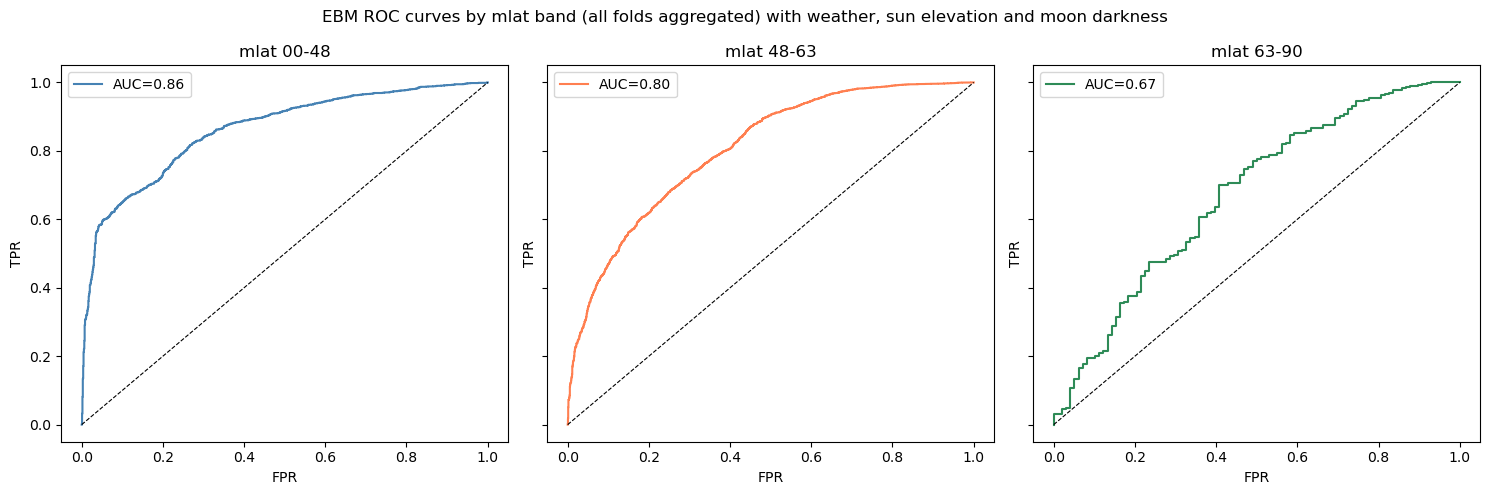

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
bands = sorted(fit_results2_df['mlat_band'].unique())
colors = ['steelblue', 'coral', 'seagreen']

for ax, band, color in zip(axes, bands, colors):
      grp = fit_results2_df[fit_results2_df['mlat_band'] == band]
      y_true_all = sum(grp['y_val'].tolist(), [])
      y_prob_all = sum(grp['y_prob'].tolist(), [])

      fpr, tpr, _ = roc_curve(y_true_all, y_prob_all)
      roc_auc = auc(fpr, tpr)
      ax.plot(fpr, tpr, color=color, label=f'AUC={roc_auc:.2f}')
      ax.plot([0,1],[0,1],'k--', linewidth=0.8)
      ax.set(title=f'mlat {band}', xlabel='FPR', ylabel='TPR')
      ax.legend()

plt.suptitle('EBM ROC curves by mlat band (all folds aggregated) with weather, sun elevation and moon darkness')
plt.tight_layout()
save_fig(fig,'ebm_roc_tt_tv_bands')
plt.show()

Saved: plots/20260731/ebm_pr_confusion_tt_tv_bands.png


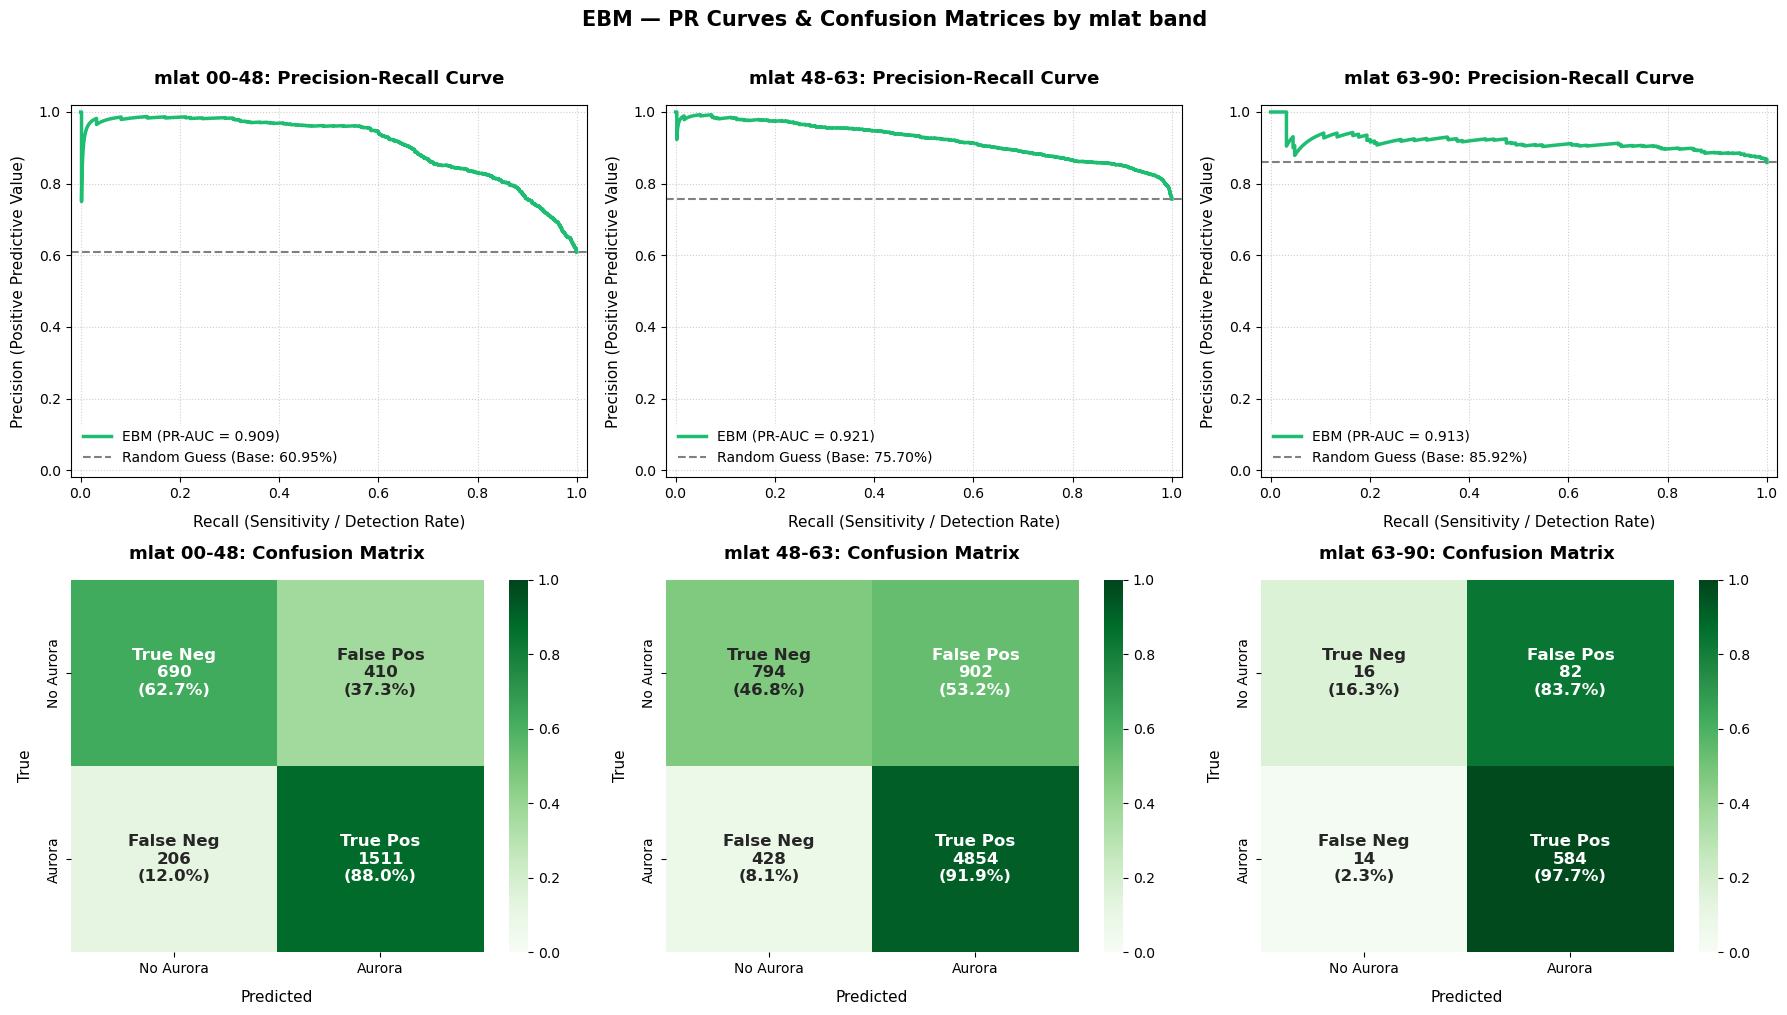

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for col, band in enumerate(bands):
      grp = fit_results2_df[fit_results2_df['mlat_band'] == band]
      y_true_all = np.array(sum(grp['y_val'].tolist(),  []))
      y_prob_all = np.array(sum(grp['y_prob'].tolist(), []))
      y_pred_all = np.array(sum(grp['y_pred'].tolist(), []))

      # ── PR Curve 
      precisions, recalls, _ = precision_recall_curve(y_true_all, y_prob_all)
      pr_auc = auc(recalls, precisions)
      baseline_ratio = y_true_all.mean()

      ax = axes[0, col]
      ax.plot(recalls, precisions, color='#1ebd71', lw=2.5, label=f'EBM (PR-AUC = {pr_auc:.3f})')
      ax.axhline(y=baseline_ratio, color='gray', lw=1.5, linestyle='--',
  label=f'Random Guess (Base: {baseline_ratio:.2%})')
      ax.set_xlim([-0.02, 1.02])
      ax.set_ylim([-0.02, 1.02])
      ax.set_xlabel('Recall (Sensitivity / Detection Rate)', fontsize=11,
  labelpad=10)
      ax.set_ylabel('Precision (Positive Predictive Value)', fontsize=11,
  labelpad=10)
      ax.set_title(f'mlat {band}: Precision-Recall Curve', fontsize=13,
  weight='bold', pad=15)
      ax.grid(True, linestyle=':', alpha=0.6)
      ax.legend(loc='lower left', frameon=True, facecolor='white',
  edgecolor='none')
  
   
      cm = confusion_matrix(y_true_all, y_pred_all)
      cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)
      labels = np.array([
          [f"True Neg\n{cm[0,0]}\n({cm_normalized[0,0]:.1%})", f"False Pos\n{cm[0,1]}\n({cm_normalized[0,1]:.1%})"],
          [f"False Neg\n{cm[1,0]}\n({cm_normalized[1,0]:.1%})", f"True Pos\n{cm[1,1]}\n({cm_normalized[1,1]:.1%})"]
      ])    

      ax = axes[1, col]
      sns.heatmap(cm_normalized, annot=labels, fmt="", cmap="Greens",
  cbar=True,
                  xticklabels=['No Aurora', 'Aurora'], yticklabels=['No Aurora', 'Aurora'],
                  vmin=0, vmax=1, ax=ax, annot_kws={"size": 12, "weight":
  "bold"})  
      ax.set_xlabel('Predicted', fontsize=11, labelpad=10)
      ax.set_ylabel('True', fontsize=11, labelpad=10)
      ax.set_title(f'mlat {band}: Confusion Matrix', fontsize=13,
  weight='bold', pad=15)

plt.suptitle('EBM — PR Curves & Confusion Matrices by mlat band',
  fontsize=15, weight='bold', y=1.01)
plt.tight_layout()
save_fig(fig,'ebm_pr_confusion_tt_tv_bands')
plt.show()

Training on the full training set, data upto July 1st 2024

In [27]:
# sw_full = per_band_weights_with_activity(
#       dataclean_timesorted_alt_train[target].astype(int),
#       dataclean_timesorted_alt_train['mlat_band'],dataclean_timesorted_alt_train['activities_id']
#   )
sw_full = per_band_weights(
      dataclean_timesorted_alt_train[target].astype(int),
      dataclean_timesorted_alt_train['mlat_band']
  )
  
  # Sanity check weights
print("Band counts in full training set:")
print(dataclean_timesorted_alt_train['mlat_band'].value_counts())
print()
print("Weight stats per band:")
bands_arr = np.array(dataclean_timesorted_alt_train['mlat_band'])
y_arr     = np.array(dataclean_timesorted_alt_train[target].astype(int))
for band in np.unique(bands_arr[~pd.isnull(bands_arr)]):
      mask = bands_arr == band
      neg_w = sw_full[mask & (y_arr == 0)]
      pos_w = sw_full[mask & (y_arr == 1)]
      neg_str = f"{neg_w[0]:.4f}" if len(neg_w) > 0 else "N/A"
      pos_str = f"{pos_w[0]:.4f}" if len(pos_w) > 0 else "N/A"
      print(f"  {band}: neg_w={neg_str}  pos_w={pos_str}  n={mask.sum()}")


# Fit on full training set
X_train_full = dataclean_timesorted_alt_train[featureslow]
y_train_full = dataclean_timesorted_alt_train[target].astype(int)

pipeebm2.fit(X_train_full, y_train_full, EBM__sample_weight=sw_full)

# Training set predictions
y_predict_fulltrain_prob = pipeebm2.predict_proba(X_train_full)[:, 1]
y_predict_fulltrain      = (y_predict_fulltrain_prob >= 0.5).astype(int)

mlat_train_full = dataclean_timesorted_alt_train['mlat_band']
bands = sorted(dataclean_timesorted_alt_train['mlat_band'].dropna().unique())

print("\n=== Per-band Train Set Scores ===")
for band in bands:
      mask = (mlat_train_full == band).values
      if mask.sum() < 10:
            continue

      y_band    = y_train_full[mask]
      y_prob    = y_predict_fulltrain_prob[mask]
      y_pred    = y_predict_fulltrain[mask]

      print(f'\n=== {band} (n={mask.sum()}) ===')
      print(f'  F1={f1_score(y_band, y_pred):.3f}  '
            f'Recall={recall_score(y_band, y_pred):.3f}  '
            f'Precision={precision_score(y_band, y_pred):.3f}')
      print(f'  ROC-AUC={roc_auc_score(y_band, y_prob):.3f}  '
            f'PR-AUC={average_precision_score(y_band, y_prob):.3f}  '
            f'Brier={brier_score_loss(y_band, y_prob):.3f}')

        

train_scores_full = {
'f1'        : f1_score(y_train_full, y_predict_fulltrain),
'recall'    : recall_score(y_train_full, y_predict_fulltrain),
'precision' : precision_score(y_train_full, y_predict_fulltrain),
'roc_auc'   : roc_auc_score(y_train_full, y_predict_fulltrain_prob),
'pr_auc'    : average_precision_score(y_train_full, y_predict_fulltrain_prob),  
'brier'     : brier_score_loss(y_train_full, y_predict_fulltrain)}
print(train_scores_full)
ebm_global_full = pipeebm2.named_steps['EBM'].explain_global()
show(ebm_global_full)

Band counts in full training set:
mlat_band
48-63    9642
00-48    3005
63-90    1342
Name: count, dtype: int64

Weight stats per band:
  00-48: neg_w=1.2176  pos_w=0.8484  n=3005
  48-63: neg_w=2.0180  pos_w=0.6647  n=9642
  63-90: neg_w=3.9012  pos_w=0.5735  n=1342

=== Per-band Train Set Scores ===

=== 00-48 (n=3005) ===
  F1=0.863  Recall=0.818  Precision=0.912
  ROC-AUC=0.908  PR-AUC=0.938  Brier=0.117

=== 48-63 (n=9642) ===
  F1=0.896  Recall=0.858  Precision=0.937
  ROC-AUC=0.912  PR-AUC=0.965  Brier=0.114

=== 63-90 (n=1342) ===
  F1=0.867  Recall=0.799  Precision=0.946
  ROC-AUC=0.856  PR-AUC=0.975  Brier=0.156
{'f1': 0.8868060562364816, 'recall': 0.8446144791053561, 'precision': 0.9334345186470078, 'roc_auc': 0.9093529920077505, 'pr_auc': 0.9595668916301612, 'brier': 0.15712345414254056}


<!-- http://127.0.0.1:7001/140211240511600/ -->

Sanity check, the model needs to learn this!

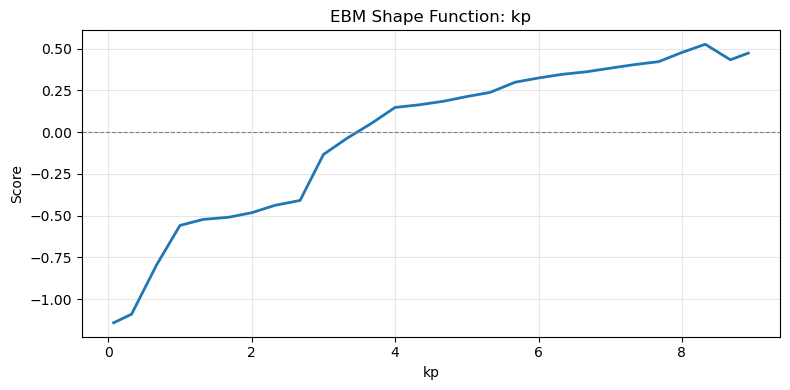

In [28]:
feature_name = 'kp'
names = ebm_global_full.data()['names']
idx   = names.index(feature_name)

# extract shape data
d = ebm_global_full.data(idx)
edges = d['names']
y     = d['scores']
x     = [(edges[i] + edges[i+1]) / 2 for i in range(len(edges) - 1)]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, y, lw=2)
ax.axhline(0, color='gray', lw=0.8, linestyle='--')
ax.set_xlabel(feature_name)
ax.set_ylabel('Score')
ax.set_title(f'EBM Shape Function: {feature_name}')
ax.grid(alpha=0.3)  
plt.tight_layout()
plt.show()



Saved: plots/20260731/ebm_roc_fulltrain_bands.png


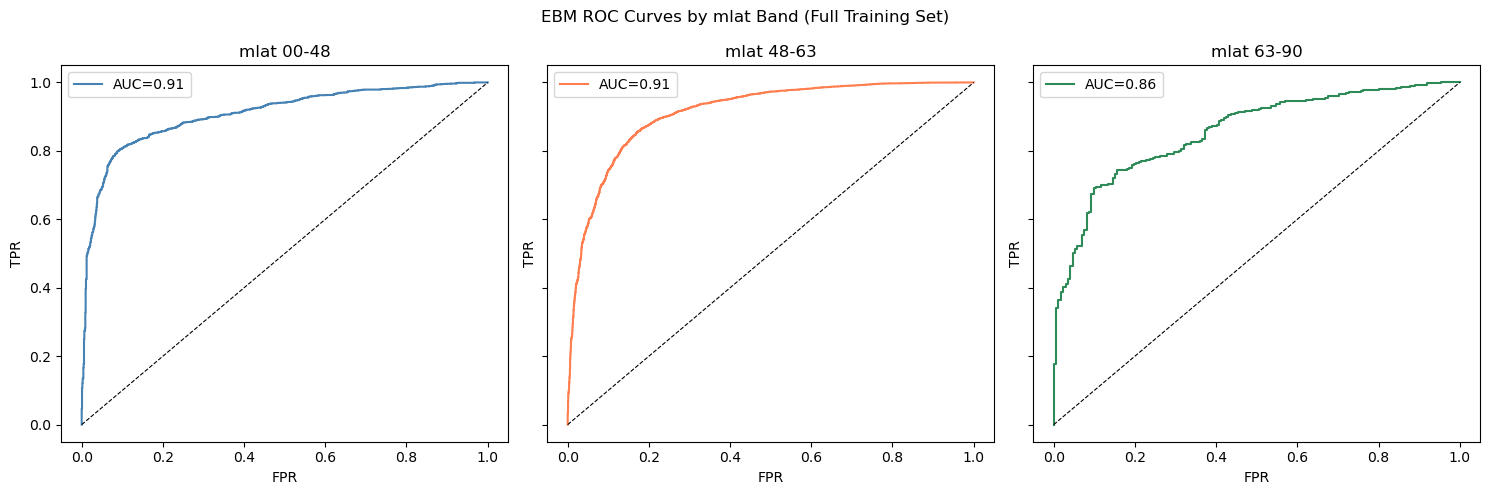

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
colors = ['steelblue', 'coral', 'seagreen']

for ax, band, color in zip(axes, bands, colors):
      mask = (mlat_train_full == band).values
      y_true = y_train_full[mask]
      y_prob = y_predict_fulltrain_prob[mask]

      fpr, tpr, _ = roc_curve(y_true, y_prob)
      roc_auc = roc_auc_score(y_true, y_prob)
      ax.plot(fpr, tpr, color=color, label=f'AUC={roc_auc:.2f}')
      ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
      ax.set(title=f'mlat {band}', xlabel='FPR', ylabel='TPR')
      ax.legend()

plt.suptitle('EBM ROC Curves by mlat Band (Full Training Set)')
plt.tight_layout()
save_fig(fig,'ebm_roc_fulltrain_bands')
plt.show()

Saved: plots/20260731/ebm_calib_fulltrain_bands.png


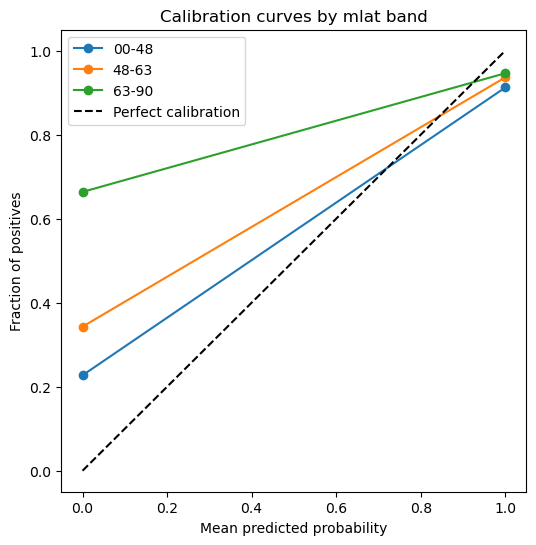

In [30]:
fig, ax = plt.subplots(figsize=(6, 6))
for band in bands:
    mask = (mlat_train_full == band).values
    if mask.sum() < 10:
        continue
    frac_pos, mean_pred = calibration_curve(
        y_train_full[mask], y_predict_fulltrain[mask], n_bins=10
    )
    ax.plot(mean_pred, frac_pos, marker='o', label=band)

ax.plot([0,1],[0,1], 'k--', label='Perfect calibration')
ax.set(xlabel='Mean predicted probability', ylabel='Fraction of positives',
        title='Calibration curves by mlat band')
ax.legend()
save_fig(fig,'ebm_calib_fulltrain_bands')
plt.show()

Saved: plots/20260731/ebm_pr_confusion_fulltrain_bands.png


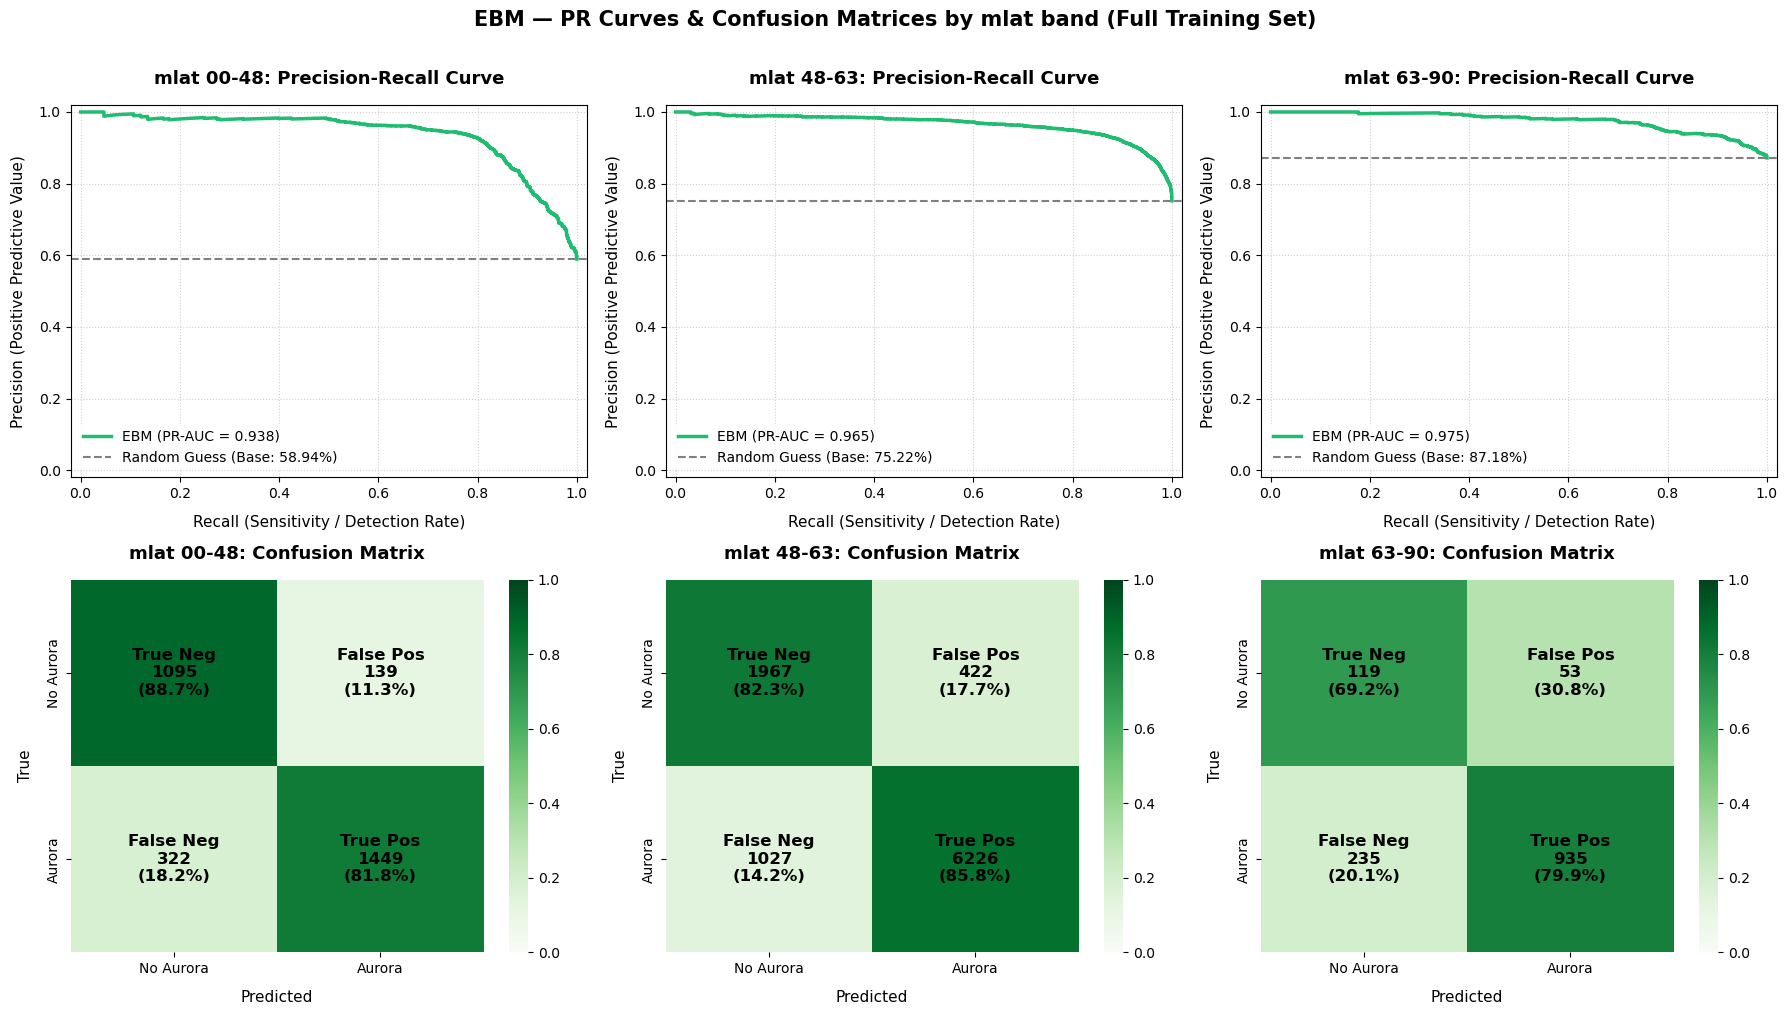

In [31]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

y_prob_train = pipeebm2.predict_proba(X_train_full[featureslow])[:, 1]
y_pred_train = (y_prob_train >= 0.5).astype(int)
y_true_train = np.array(y_train_full)
bands_train  = np.array(mlat_train_full)

for col, band in enumerate(bands):
    mask       = bands_train == band
    y_true_all = y_true_train[mask]
    y_prob_all = y_prob_train[mask]
    y_pred_all = y_pred_train[mask]

    # ── PR Curve
    precisions, recalls, _ = precision_recall_curve(y_true_all, y_prob_all)
    pr_auc         = average_precision_score(y_true_all, y_prob_all)
    baseline_ratio = y_true_all.mean()

    ax = axes[0, col]
    ax.plot(recalls, precisions, color='#1ebd71', lw=2.5, label=f'EBM (PR-AUC = {pr_auc:.3f})')
    ax.axhline(y=baseline_ratio, color='gray', lw=1.5, linestyle='--',
            label=f'Random Guess (Base: {baseline_ratio:.2%})')
    ax.set_xlim([-0.02, 1.02])
    ax.set_ylim([-0.02, 1.02])
    ax.set_xlabel('Recall (Sensitivity / Detection Rate)', fontsize=11,
    labelpad=10)
    ax.set_ylabel('Precision (Positive Predictive Value)', fontsize=11,
    labelpad=10)
    ax.set_title(f'mlat {band}: Precision-Recall Curve', fontsize=13,
    weight='bold', pad=15)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(loc='lower left', frameon=True, facecolor='white',
    edgecolor='none')

# ── Confusion Matrix
    cm            = confusion_matrix(y_true_all, y_pred_all)
    cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    labels        = np.array([
    [f"True Neg\n{cm[0,0]}\n({cm_normalized[0,0]:.1%})", f"False Pos\n{cm[0,1]}\n({cm_normalized[0,1]:.1%})"],
    [f"False Neg\n{cm[1,0]}\n({cm_normalized[1,0]:.1%})", f"True Pos\n{cm[1,1]}\n({cm_normalized[1,1]:.1%})"]
    ])    

    ax = axes[1, col]
    sns.heatmap(cm_normalized, annot=labels, fmt="", cmap="Greens",
    cbar=True,
            xticklabels=['No Aurora', 'Aurora'], yticklabels=['No Aurora', 'Aurora'],
            vmin=0, vmax=1, ax=ax, annot_kws={"size": 12, "weight":
    "bold", "color": "black"})
    ax.set_xlabel('Predicted', fontsize=11, labelpad=10)
    ax.set_ylabel('True', fontsize=11, labelpad=10)
    ax.set_title(f'mlat {band}: Confusion Matrix', fontsize=13,
    weight='bold', pad=15)

plt.suptitle('EBM — PR Curves & Confusion Matrices by mlat band (Full Training Set)',fontsize=15, weight='bold', y=1.01)
plt.tight_layout()
save_fig(fig,'ebm_pr_confusion_fulltrain_bands')
plt.show()


Working on held out test data from 01st July 2024 to 31st July 2025

In [32]:
X_test_full      = dataclean_timesorted_alt_test[featureslow]
y_test_full      = dataclean_timesorted_alt_test[target].astype(int)
mlat_test        = dataclean_timesorted_alt_test['mlat_band']

y_predict_test_prob = pipeebm2.predict_proba(X_test_full)[:, 1]
y_predict_test      = (y_predict_test_prob >= 0.5).astype(int)

print('=== Per-band Test Set Scores ===\n')

for band in mlat_regions:
    mask   = (mlat_test == band).values
    if mask.sum() == 0:
        continue
    y_band     = y_test_full.values[mask]
    prob_band  = y_predict_test_prob[mask]
    pred_band  = y_predict_test[mask]

    f1  = f1_score(y_band, pred_band, zero_division=0)
    rec = recall_score(y_band, pred_band, zero_division=0)
    pre = precision_score(y_band, pred_band, zero_division=0)
    auc = roc_auc_score(y_band, prob_band)
    pr  = average_precision_score(y_band, prob_band)
    bri = brier_score_loss(y_band, prob_band)

    print(f'=== {band} (n={mask.sum()}) ===')
    print(f'  F1={f1:.3f}  Recall={rec:.3f}  Precision={pre:.3f}')
    print(f'  ROC-AUC={auc:.3f}  PR-AUC={pr:.3f}  Brier={bri:.3f}\n')

=== Per-band Test Set Scores ===

=== 00-48 (n=1688) ===
  F1=0.825  Recall=0.836  Precision=0.815
  ROC-AUC=0.829  PR-AUC=0.902  Brier=0.162

=== 48-63 (n=6253) ===
  F1=0.815  Recall=0.742  Precision=0.903
  ROC-AUC=0.835  PR-AUC=0.927  Brier=0.168

=== 63-90 (n=244) ===
  F1=0.885  Recall=0.857  Precision=0.914
  ROC-AUC=0.756  PR-AUC=0.944  Brier=0.154



Saved: plots/20260731/ebm_roc_test_bands.png


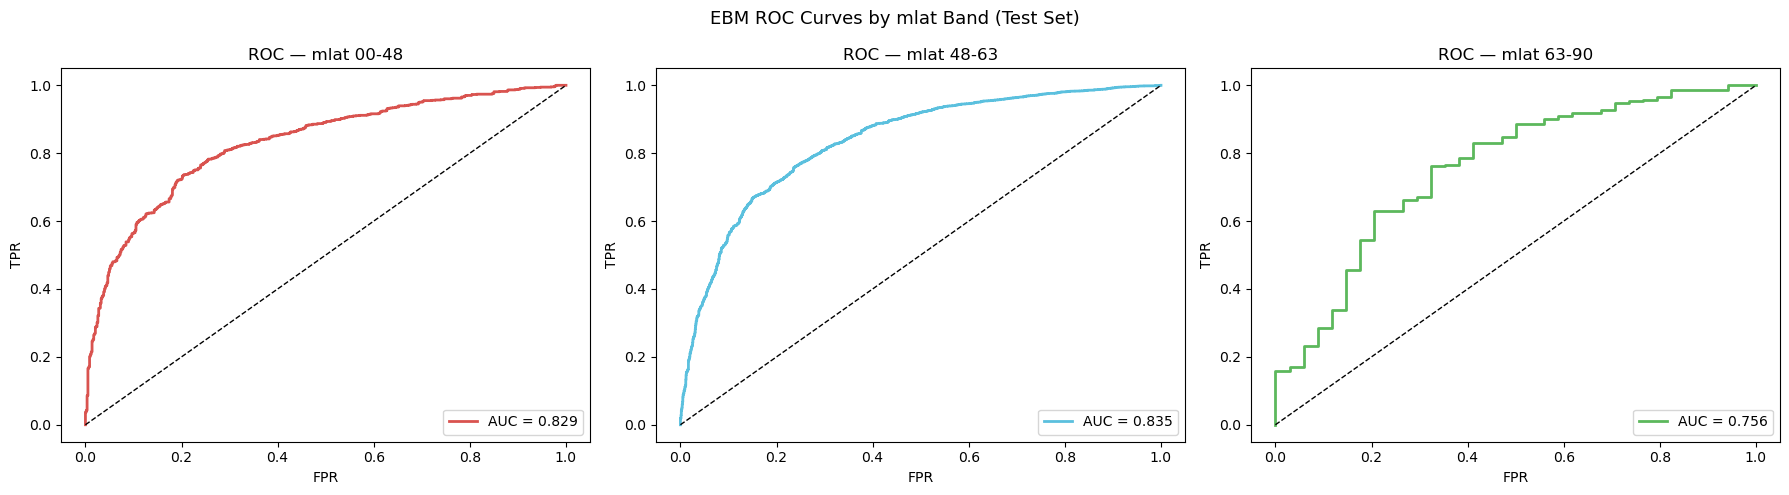

Saved: plots/20260731/ebm_pr_test_bands.png


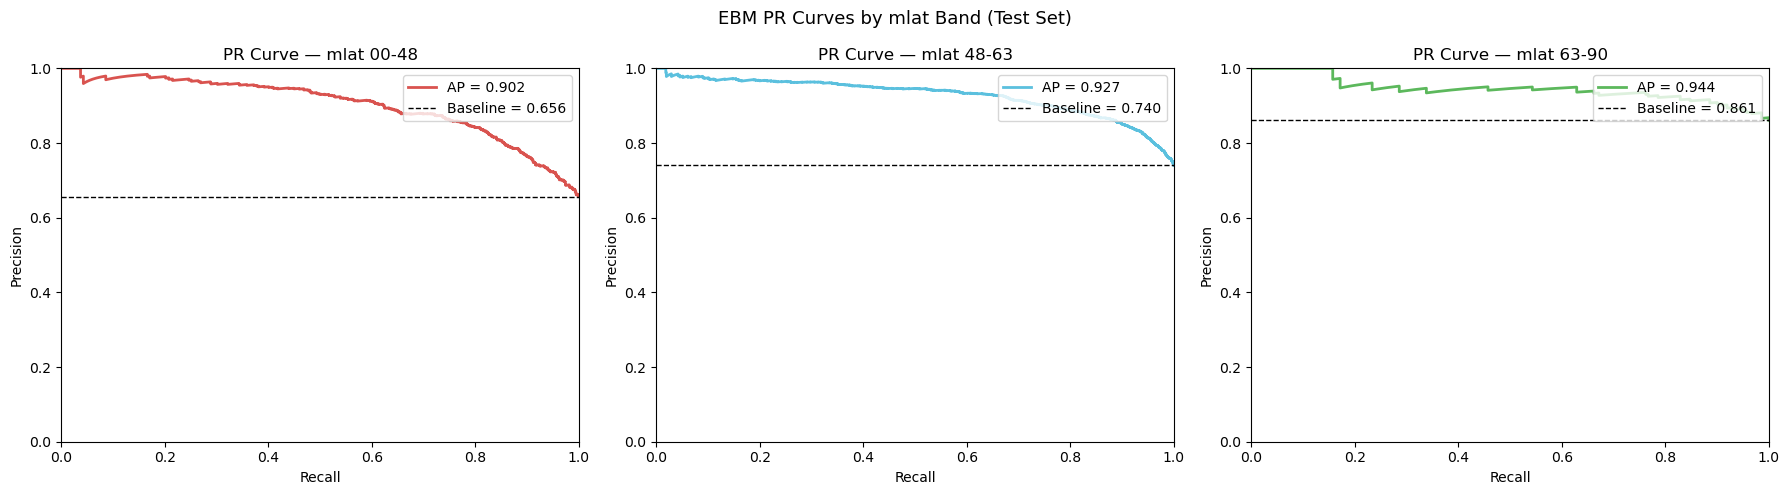

Saved: plots/20260731/ebm_confusion_test_bands.png


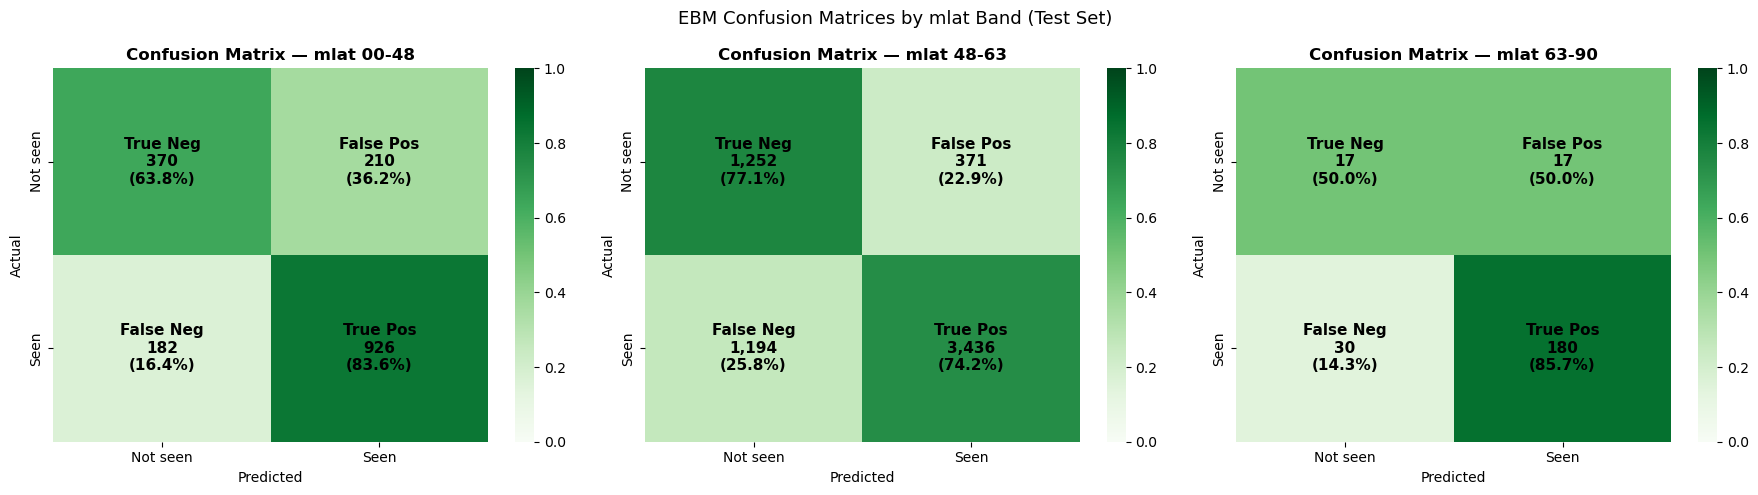

In [33]:
 # ── Test set predictions 
X_test_full      = dataclean_timesorted_alt_test[featureslow]
y_test_full      = dataclean_timesorted_alt_test[target].astype(int)
mlat_test        = dataclean_timesorted_alt_test['mlat_band']

y_predict_test_prob = pipeebm2.predict_proba(X_test_full)[:, 1]
y_predict_test      = (y_predict_test_prob >= 0.5).astype(int)


bands  = sorted(dataclean_timesorted_alt_test['mlat_band'].dropna().unique())
colors = {'00-48': '#d9534f', '48-63': '#5bc0de', '63-90': '#5cb85c'}

# ── ROC Curves 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, band in zip(axes, bands):
    mask = (mlat_test == band).values
    if mask.sum() < 10:
        ax.text(0.5, 0.5, f'Insufficient data\n(n={mask.sum()})',
                ha='center', va='center', transform=ax.transAxes)
        ax.set(title=f'ROC — mlat {band}')
        continue
    fpr, tpr, _ = roc_curve(y_test_full.values[mask],y_predict_test_prob[mask])
    roc_auc     = roc_auc_score(y_test_full[mask], y_predict_test_prob[mask])
    ax.plot(fpr, tpr, color=colors[band], lw=2, label=f'AUC = {roc_auc:.3f}')
    ax.plot([0,1], [0,1], 'k--', lw=1)
    ax.set(title=f'ROC — mlat {band}', xlabel='FPR', ylabel='TPR')
    ax.legend(loc='lower right')
plt.suptitle('EBM ROC Curves by mlat Band (Test Set)', fontsize=13)
plt.tight_layout()
save_fig(fig,'ebm_roc_test_bands')
plt.show()
# ── PR Curves 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, band in zip(axes, bands):
    mask = (mlat_test == band).values
    if mask.sum() < 10:
        continue
    precision, recall, _ = precision_recall_curve(y_test_full[mask],y_predict_test_prob[mask])
    ap       = average_precision_score(y_test_full[mask],y_predict_test_prob[mask])
    baseline = y_test_full[mask].mean()
    ax.plot(recall, precision, color=colors[band], lw=2, label=f'AP = {ap:.3f}')
    ax.axhline(baseline, color='k', linestyle='--', lw=1, label=f'Baseline = {baseline:.3f}')
    ax.set(title=f'PR Curve — mlat {band}', xlabel='Recall',ylabel='Precision',xlim=[0,1], ylim=[0,1])
    ax.legend(loc='upper right')
plt.suptitle('EBM PR Curves by mlat Band (Test Set)', fontsize=13)
plt.tight_layout()
save_fig(fig,'ebm_pr_test_bands')
plt.show()

# ── Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))


for ax, band in zip(axes, bands):
    mask = (mlat_test == band).values
    if mask.sum() < 10:
        continue
    cm = confusion_matrix(y_test_full[mask], y_predict_test[mask])
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    labels = np.array([
        [f"True Neg\n{cm[0,0]:,}\n({cm_normalized[0,0]:.1%})",
        f"False Pos\n{cm[0,1]:,}\n({cm_normalized[0,1]:.1%})"],
        [f"False Neg\n{cm[1,0]:,}\n({cm_normalized[1,0]:.1%})",
        f"True Pos\n{cm[1,1]:,}\n({cm_normalized[1,1]:.1%})"]
    ])    

    sns.heatmap(cm_normalized, annot=labels, fmt='', cmap='Greens',
                vmin=0, vmax=1, ax=ax, cbar=True,
                xticklabels=['Not seen', 'Seen'],
                yticklabels=['Not seen', 'Seen'],
                annot_kws={'size': 11, 'weight': 'bold', 'color': 'black'})

    ax.set_title(f'Confusion Matrix — mlat {band}', fontsize=12,
weight='bold')
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('Actual', fontsize=10)

plt.suptitle('EBM Confusion Matrices by mlat Band (Test Set)', fontsize=13)
plt.tight_layout()
save_fig(fig,'ebm_confusion_test_bands')
plt.show()


Saved: plots/20260731/perband_test_scores_noact.png


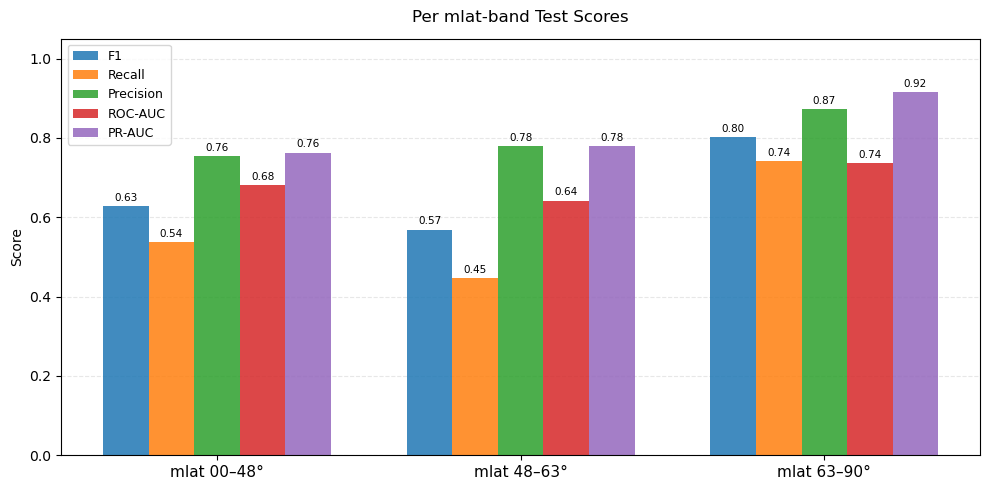

In [34]:
bands   = ["00–48", "48–63", "63–90"]
metrics = {
    "F1":      [0.628, 0.569, 0.802],
    "Recall":  [0.537, 0.447, 0.742],
    "Precision":[0.755, 0.780, 0.873],
    "ROC-AUC": [0.681, 0.642, 0.736],
    "PR-AUC":  [0.763, 0.780, 0.916],
}

x     = np.arange(len(bands))
width = 0.15
colors = ["#4e9af1", "#f18f4e", "#6dd47e", "#f14e4e", "#c46df1"]

fig, ax = plt.subplots(figsize=(10, 5))


for i, (label, vals) in enumerate(metrics.items()):
      offset = (i - 2) * width
      bars = ax.bar(x + offset, vals, width, label=label, alpha=0.85)
      for bar, v in zip(bars, vals):
          ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
                  f"{v:.2f}", ha='center', va='bottom', fontsize=7.5)

  
ax.set_xticks(x)
ax.set_xticklabels([f"mlat {b}°" for b in bands], fontsize=11)
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.yaxis.grid(True, alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
ax.legend(loc='upper left', fontsize=9)
ax.set_title("Per mlat-band Test Scores", fontsize=12, pad=12)

plt.tight_layout()
save_fig(fig, "perband_test_scores_noact")
plt.show()



In [35]:
wrong = dataclean_timesorted_alt_train.copy()
wrong['prob'] = y_predict_fulltrain_prob
wrong['pred'] = y_predict_fulltrain

false_negatives = wrong[(wrong[target]==True)  & (wrong['pred']==0)]
false_positives = wrong[(wrong[target]==False) & (wrong['pred']==1)]

print(false_negatives[['mlat','kp','bz_gsm','cloud_cover','solar_wind_speed']]
.describe())
print(false_positives[['mlat','kp','bz_gsm','cloud_cover','solar_wind_speed']]
.describe())

              mlat           kp       bz_gsm  cloud_cover  solar_wind_speed
count  1584.000000  1584.000000  1584.000000  1584.000000       1584.000000
mean     50.620083     3.673990    -0.864036    43.647727        634.414773
std      15.632037     2.384837     4.370166    41.628379        685.436127
min     -53.482966     0.000000   -29.933333     0.000000        275.666667
25%      48.578855     1.700000    -2.533333     0.000000        394.333333
50%      52.447651     3.300000    -0.433333    33.500000        491.666667
75%      56.471092     5.700000     1.566667    93.000000        696.416667
max      78.165580     9.000000    16.700000   100.000000       6820.666667
             mlat          kp      bz_gsm  cloud_cover  solar_wind_speed
count  614.000000  614.000000  614.000000   614.000000        614.000000
mean    51.820623    5.773453   -8.148643    35.837134        616.839305
std     14.718810    2.567489    8.647165    39.585324        417.482767
min    -53.645232    0.7

(array([ 917.,  508.,  406.,  420.,  383.,  335.,  321.,  266.,  270.,
         281.,  254.,  265.,  259.,  261.,  300.,  310.,  385.,  421.,
         547.,  780.,  965., 1091., 1637., 1691.,  716.]),
 array([0.0013883 , 0.04109956, 0.08081083, 0.12052209, 0.16023335,
        0.19994462, 0.23965588, 0.27936714, 0.31907841, 0.35878967,
        0.39850093, 0.4382122 , 0.47792346, 0.51763472, 0.55734599,
        0.59705725, 0.63676851, 0.67647977, 0.71619104, 0.7559023 ,
        0.79561356, 0.83532483, 0.87503609, 0.91474735, 0.95445862,
        0.99416988]),
 <BarContainer object of 25 artists>)

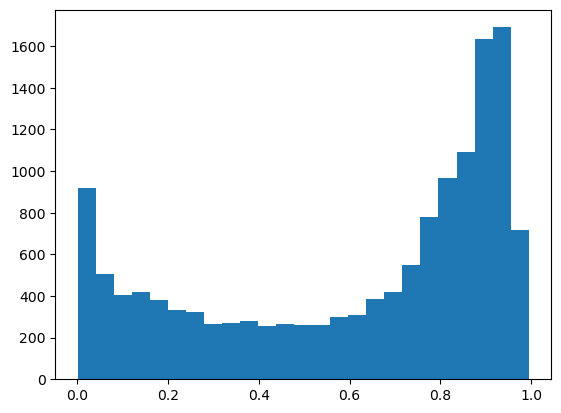

In [36]:
plt.hist(y_predict_fulltrain_prob, bins=25)

In [37]:
y_test_arr   = dataclean_timesorted_alt_test["see_aurora"]
probs_test   = pipeebm2.predict_proba(dataclean_timesorted_alt_test[featureslow])[:, 1]
preds_test   = (probs_test >= 0.3).astype(int)

fn_mask = (y_test_arr == 1) & (preds_test == 0)
fn_idx  = np.where(fn_mask)[0]
print(f'False negatives: {fn_mask.sum()}')
print(dataclean_timesorted_alt_test[featureslow].iloc[fn_idx[:5]][['mlat', 'kp', 'bz_gsm', 'oval_dist',
'sun_elevation_utc']])

# Pick first false negative and explain
sample_idx = fn_idx[0]
X_fn = dataclean_timesorted_alt_test[featureslow].iloc[[sample_idx]]
y_fn = dataclean_timesorted_alt_test["see_aurora"].iloc[[sample_idx]]

X_fn_transformed = pipeebm2[:-1].transform(X_fn)

ebm = pipeebm2.named_steps['EBM']
show(ebm.explain_local(X_fn_transformed, y_fn.values), 0)

False negatives: 623
            mlat   kp    bz_gsm  oval_dist  sun_elevation_utc
13991  54.232426  1.3 -1.333333  -9.167574         -13.131175
14013  52.204117  2.3 -0.200000  -9.195883         -11.726719
14023  57.966824  1.3  1.900000  -5.433176          -1.392073
14024  57.962919  1.3  1.900000  -5.437081          -5.955423
14030  47.971699  1.0  1.100000 -16.028301         -11.645870


<!-- http://127.0.0.1:7001/140211241679328/ -->

In [38]:
y_test_arr   = dataclean_timesorted_alt_test["see_aurora"]
probs_test   = pipeebm2.predict_proba(dataclean_timesorted_alt_test[featureslow])[:, 1]
preds_test   = (probs_test >= 0.5).astype(int)

fn_mask = (y_test_arr == 0) & (preds_test == 1)
fn_idx  = np.where(fn_mask)[0]
print(f'False positive: {fn_mask.sum()}')
print(dataclean_timesorted_alt_test[featureslow].iloc[fn_idx[:5]][['mlat', 'kp', 'bz_gsm', 'oval_dist',
'sun_elevation_utc']])

# Pick first false negative and explain
sample_idx = fn_idx[0]
X_fn = dataclean_timesorted_alt_test[featureslow].iloc[[sample_idx]]
y_fn = dataclean_timesorted_alt_test["see_aurora"].iloc[[sample_idx]]

X_fn_transformed = pipeebm2[:-1].transform(X_fn)

ebm = pipeebm2.named_steps['EBM']
show(ebm.explain_local(X_fn_transformed, y_fn.values), 0)

False positive: 598
            mlat   kp    bz_gsm  oval_dist  sun_elevation_utc
14048  53.495066  5.0 -5.300000  -2.504934         -18.750468
14051  52.636549  5.0 -5.300000  -3.363451         -22.947385
14058  42.989599  5.0 -5.300000 -13.010401         -21.223766
14061  54.089679  4.0 -0.566667  -3.910321         -18.097898
14090  33.068961  1.7  0.266667 -29.531039         -28.804847


<!-- http://127.0.0.1:7001/140209668471504/ -->

# Predictions based on limited July 4th, 2026 geomagnetic indices data

In [ ]:
import aacgmv2
import datetime                                       
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from astral.sun import elevation as sun_elevation_fn
from astral import Observer


KP_TO_AP = {0:0, 1:3, 2:7, 3:15, 4:27, 5:48, 6:80, 7:140, 8:240, 9:400}

kp_input = 7
dt       = datetime.datetime(2026, 7, 4, 0, 0, 0)
dt_utc   = dt.replace(tzinfo=datetime.timezone.utc)

# ── Geographic grid
geo_lats = np.arange(30, 91, 1, dtype=float)
geo_lons = np.arange(-180, 181, 2, dtype=float)
geo_lon_mesh, geo_lat_mesh = np.meshgrid(geo_lons, geo_lats)

geo_lat_flat = geo_lat_mesh.flatten()
geo_lon_flat = geo_lon_mesh.flatten()

# ── AACGM conversion: geographic → mlat, mlon, mlt
mlat_flat, mlon_flat, mlt_flat = aacgmv2.get_aacgm_coord_arr(
    geo_lat_flat, geo_lon_flat,
    np.zeros_like(geo_lat_flat),
    dt
)

# ── oval_dist —  Feldstein & Starkov 1967
mlt_angle      = np.pi * mlt_flat / 12
oval_dist_flat = np.abs(mlat_flat) - (65.2 - 2.4 * kp_input)

# ── real per-point sun elevation (was a flat -30.0)
sun_elev_flat = np.array([
    sun_elevation_fn(Observer(latitude=la, longitude=lo), dt_utc)
    for la, lo in zip(geo_lat_flat, geo_lon_flat)
])

# ── Build prediction DataFrame
sweep_df = pd.DataFrame({
    'mlat':              mlat_flat,
    'mlon':              mlon_flat,
    'kp':                float(kp_input),
    'bz_gsm':           -7.0,
    'sigma_bz_gsm':      7.0,
    'solar_wind_speed':  550.0,
    'Ap':                float(KP_TO_AP.get(kp_input, 27)),
    'oval_dist':         oval_dist_flat,
    'cloud_cover':       0.0,
    'sun_elevation_utc': sun_elev_flat,
    'moon_darkness':     1.0,
})

# Drop rows where AACGM returned NaN
valid = sweep_df.notna().all(axis=1)
probs = np.full(len(sweep_df), np.nan)
probs[valid] = pipeebm2.predict_proba(sweep_df.loc[valid, featureslow])[:,
1]

print(f'Max prob    : {np.nanmax(probs):.4f}')
print(f'Mean prob   : {np.nanmean(probs):.4f}')
print(f'probs >= 0.3: {(probs >= 0.3).sum()}')
print(f'probs >= 0.5: {(probs >= 0.5).sum()}')
print(f'probs >= 0.7: {(probs >= 0.7).sum()}')

# ── Plot
threshold = 0.80
mask = (probs >= threshold) & ~np.isnan(probs)

fig, ax = plt.subplots(1, 1, figsize=(8, 8),
                        subplot_kw={'projection': ccrs.NorthPolarStereo()})

ax.add_feature(cfeature.LAND,      facecolor='lightgray')
ax.add_feature(cfeature.OCEAN,     facecolor='lightblue')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.set_extent([-180, 180, 30, 90], crs=ccrs.PlateCarree())

if mask.sum() > 0:
    sc = ax.scatter(
      geo_lon_flat[mask], geo_lat_flat[mask],
      c=probs[mask], cmap='plasma', vmin=0.8, vmax=1,
      s=150, marker='o', linewidths=0,
      transform=ccrs.PlateCarree()
  )

    cbar = plt.colorbar(sc, ax=ax, orientation='horizontal',
                fraction=0.03, pad=0.05, label='P(aurora visible)')
    cbar.set_ticks([0.8, 0.85, 0.9, 0.95, 1.0])
    cbar.set_ticklabels(['0.8', '0.85', '0.9', '0.95', '1.0'])
else:
    ax.text(0.5, 0.5, 'No points above threshold',
            ha='center', va='center', transform=ax.transAxes, fontsize=12)

ax.set_title(f'Aurora visibility probability  |  Kp={kp_input}  |  '
            f'{dt.strftime("%Y-%m-%d %H:%M UTC")}',
            fontsize=11, weight='bold')

plt.tight_layout()
save_fig(fig,'july4th_pred')
plt.show()
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import aacgmv2
import datetime

kp_input = 7
prob_threshold = 0.80
dt = datetime.datetime(2026, 7, 4, 0, 0, 0)
dt_utc = dt.replace(tzinfo=datetime.timezone.utc)

geo_lats = np.arange(30, 91, 1, dtype=float)
geo_lons = np.arange(-180, 181, 2, dtype=float)
geo_lon_mesh, geo_lat_mesh = np.meshgrid(geo_lons, geo_lats)
geo_lat_flat = geo_lat_mesh.flatten()
geo_lon_flat = geo_lon_mesh.flatten()

mlat_flat, mlon_flat, mlt_flat = aacgmv2.get_aacgm_coord_arr(
    geo_lat_flat, geo_lon_flat, np.zeros_like(geo_lat_flat), dt)

oval_dist_flat = np.abs(mlat_flat) - (65.2 - 2.4 * kp_input)

sun_elev_flat = np.array([
    sun_elevation_fn(Observer(latitude=la, longitude=lo), dt_utc)
    for la, lo in zip(geo_lat_flat, geo_lon_flat)
])

sweep_df = pd.DataFrame({
    'mlat':              mlat_flat,
    'mlon':              mlon_flat,
    'kp':                float(kp_input),
    'bz_gsm':           -7.0,
    'solar_wind_speed':  550.0,
    'Ap':                float(KP_TO_AP.get(kp_input, 27)),
    'oval_dist':         oval_dist_flat,
    'cloud_cover':       0.0,
    'sun_elevation_utc': sun_elev_flat,
    'moon_darkness':     1.0,
})

valid = sweep_df.notna().all(axis=1)
probs = np.full(len(sweep_df), np.nan)
probs[valid] = pipeebm2.predict_proba(sweep_df.loc[valid, featureslow])[:, 1]
prob_mesh = probs.reshape(geo_lat_mesh.shape)

fig = plt.figure(figsize=(9, 9))
fig.patch.set_facecolor('white')
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Orthographic(central_longitude=0, central_latitude=90))

ax.set_global()
ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=1)
ax.add_feature(cfeature.OCEAN, facecolor='lightblue', zorder=1)
ax.add_feature(cfeature.COASTLINE, edgecolor='#333333', lw=0.6, zorder=2)
ax.add_feature(cfeature.BORDERS, edgecolor='#888888', lw=0.3, zorder=2)
ax.gridlines(linewidth=0.5, color='gray', alpha=0.4, linestyle='--')

levels = np.linspace(prob_threshold, 1.0, 20)
cf = ax.contourf(geo_lons, geo_lats, prob_mesh, levels=levels, cmap='YlGn',
                  transform=ccrs.PlateCarree(), zorder=3)
cbar = plt.colorbar(cf, ax=ax, orientation='horizontal', fraction=0.03, pad=0.05, label='P(aurora visible)')
cbar.set_ticks([0.8, 0.85, 0.9, 0.95, 1.0])
cbar.set_ticklabels(['0.8', '0.85', '0.9', '0.95', '1.0'])

ax.set_title(f'Kp={kp_input} aurora visibility probability >= {prob_threshold}  |  {dt} UTC',
             fontsize=11, weight='bold')

plt.tight_layout()
plt.savefig("aurora_globe_kp7.png", dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import aacgmv2
import datetime

kp_input = 7
prob_threshold = 0.80
dt = datetime.datetime(2026, 7, 4, 0, 0, 0)
dt_utc = dt.replace(tzinfo=datetime.timezone.utc)

geo_lats = np.arange(30, 91, 1, dtype=float)
geo_lons = np.arange(-180, 181, 2, dtype=float)
geo_lon_mesh, geo_lat_mesh = np.meshgrid(geo_lons, geo_lats)
geo_lat_flat = geo_lat_mesh.flatten()
geo_lon_flat = geo_lon_mesh.flatten()

mlat_flat, mlon_flat, mlt_flat = aacgmv2.get_aacgm_coord_arr(
    geo_lat_flat, geo_lon_flat, np.zeros_like(geo_lat_flat), dt)

oval_dist_flat = np.abs(mlat_flat) - (65.2 - 2.4 * kp_input)

sun_elev_flat = np.array([
    sun_elevation_fn(Observer(latitude=la, longitude=lo), dt_utc)
    for la, lo in zip(geo_lat_flat, geo_lon_flat)
])

sweep_df = pd.DataFrame({
    'mlat':              mlat_flat,
    'mlon':              mlon_flat,
    'kp':                float(kp_input),
    'bz_gsm':           -7.0,
    'solar_wind_speed':  550.0,
    'Ap':                float(KP_TO_AP.get(kp_input, 27)),
    'oval_dist':         oval_dist_flat,
    'cloud_cover':       0.0,
    'sun_elevation_utc': sun_elev_flat,
    'moon_darkness':     1.0,
})

valid = sweep_df.notna().all(axis=1)
probs = np.full(len(sweep_df), np.nan)
probs[valid] = pipeebm2.predict_proba(sweep_df.loc[valid, featureslow])[:, 1]
prob_mesh = probs.reshape(geo_lat_mesh.shape)

fig = plt.figure(figsize=(9, 9))
fig.patch.set_facecolor('white')
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Orthographic(central_longitude=0, central_latitude=90))

ax.set_global()
ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=1)
ax.add_feature(cfeature.OCEAN, facecolor='lightblue', zorder=1)
ax.add_feature(cfeature.COASTLINE, edgecolor='#333333', lw=0.6, zorder=2)
ax.add_feature(cfeature.BORDERS, edgecolor='#888888', lw=0.3, zorder=2)
ax.gridlines(linewidth=0.5, color='gray', alpha=0.4, linestyle='--')

levels = np.linspace(prob_threshold, 1.0, 20)
cf = ax.contourf(geo_lons, geo_lats, prob_mesh, levels=levels, cmap='YlGn',
                  transform=ccrs.PlateCarree(), zorder=3)
cbar = plt.colorbar(cf, ax=ax, orientation='horizontal', fraction=0.03, pad=0.05, label='P(aurora visible)')
cbar.set_ticks([0.8, 0.85, 0.9, 0.95, 1.0])
cbar.set_ticklabels(['0.8', '0.85', '0.9', '0.95', '1.0'])

ax.set_title(f'Kp={kp_input} aurora visibility probability >= {prob_threshold}  |  {dt} UTC',
             fontsize=11, weight='bold')

plt.tight_layout()
plt.savefig("aurora_globe_kp7.png", dpi=150, bbox_inches='tight')
plt.show()
